# 結構方程模式 (Structural Equation Modeling, SEM)
## 從共變異數結構到參數估計的完整教材

> **承接前一份「特徵值與因素分析」教材**。因素分析回答「一堆題目背後有幾個構面」;SEM 更進一步,回答「**這些構面之間,誰影響誰、影響多大**」。
>
> **設計原則**:每章維持「**白話說明 → 數學推導 → 數值案例 → 可執行程式**」四段式。本教材會**從零手刻一個最大概似估計器**,讓你親眼看到 SEM 不是黑盒子;最後再用專業套件 `semopy` 對照。

---

## 學習地圖(SEM 的主軸)

SEM 的一切都圍繞這條核心思想旋轉:

$$
\underbrace{S}_{\text{資料的樣本共變異數矩陣}}
\;\approx\;
\underbrace{\Sigma(\theta)}_{\text{模型隱含的共變異數矩陣}}
$$

> **一句話講完 SEM**:你畫一個「誰影響誰」的模型,這個模型會**推導出一個理論上應該長怎樣的共變異數矩陣 $\Sigma(\theta)$**;SEM 的工作就是調整參數 $\theta$(路徑係數、因素負荷量、變異數),讓 $\Sigma(\theta)$ **盡量貼近**你從資料算出來的 $S$。貼得越好,模型越成立。

| 章節 | 主題 | 你會學到 |
|---|---|---|
| 第 0 章 | 環境設定 | 套件、中文字型、路徑圖繪製工具 |
| 第 1 章 | SEM 全貌 | 測量模型 + 結構模型;$S$ vs $\Sigma(\theta)$ 的核心思想 |
| 第 2 章 | 路徑分析與追蹤法則 | Wright tracing rules、直接/間接/總效果 |
| 第 3 章 | 測量模型 (CFA) | $x=\Lambda\xi+\delta$,推導 $\Sigma=\Lambda\Phi\Lambda'+\Theta$ |
| 第 4 章 | 結構模型 | $\eta=B\eta+\Gamma\xi+\zeta$,簡化式與隱含共變異數 |
| 第 5 章 | 參數估計 | 從常態概似推導 $F_{ML}$,**手刻估計器** |
| 第 6 章 | 適配度指標 | $\chi^2$、RMSEA、CFI、TLI、SRMR 的公式與計算 |
| 第 7 章 | 完整實作 | 用 `semopy` 跑潛在變項 SEM 並畫出帶估計值的路徑圖 |
| 第 8 章 | 總整理 + 練習 | 一張表貫穿全篇 + 自我檢測 |

---
## 第 0 章　環境設定

In [1]:
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from matplotlib.patches import Ellipse, FancyBboxPatch, FancyArrowPatch
from scipy.optimize import minimize

np.set_printoptions(precision=4, suppress=True)
pd.set_option("display.precision", 4)

def use_cjk_font():
    cands = ["Noto Sans CJK TC","Noto Sans CJK SC","Noto Sans TC","Microsoft JhengHei",
             "Microsoft YaHei","PingFang TC","Heiti TC","SimHei","Arial Unicode MS","WenQuanYi Zen Hei"]
    avail = {f.name for f in fm.fontManager.ttflist}
    for n in cands:
        if n in avail:
            matplotlib.rcParams["font.family"]=n; matplotlib.rcParams["axes.unicode_minus"]=False; return n
    import glob
    for fp in glob.glob("/usr/share/fonts/**/NotoSansCJK*.ttc", recursive=True):
        try:
            fm.fontManager.addfont(fp); matplotlib.rcParams["font.family"]="Noto Sans CJK TC"
            matplotlib.rcParams["axes.unicode_minus"]=False; return "Noto Sans CJK TC"
        except Exception: pass
    matplotlib.rcParams["axes.unicode_minus"]=False; return None

print("字型:", use_cjk_font() or "(無中文字型)")

字型: WenQuanYi Zen Hei


In [2]:
# === 路徑圖繪製工具(整本教材共用)===
def _trim(p1, p2, r1, r2):
    """把線段兩端各往內縮 r1, r2,讓箭頭不被節點蓋住。"""
    p1=np.array(p1,float); p2=np.array(p2,float); d=p2-p1; L=np.hypot(*d)
    if L==0: return p1,p2
    u=d/L; return p1+u*r1, p2-u*r2

def node(ax, xy, text, kind="latent", w=1.5, h=1.0, fs=10):
    x,y=xy
    if kind=="latent":
        ax.add_patch(Ellipse((x,y),w,h,facecolor="#dbeafe",edgecolor="#2563eb",lw=2,zorder=3))
    else:
        ax.add_patch(FancyBboxPatch((x-w/2,y-h/2),w,h,boxstyle="round,pad=0.02",
                     facecolor="#fef3c7",edgecolor="#d97706",lw=1.8,zorder=3))
    ax.text(x,y,text,ha="center",va="center",fontsize=fs,zorder=4)

def arrow(ax, p1, p2, label=None, curved=0.0, two_head=False, r1=0.78, r2=0.78,
          color="#374151", lw=1.7, dx=0.0, dy=0.18):
    q1,q2=_trim(p1,p2,r1,r2)
    style="<->" if two_head else "-|>"
    ax.add_patch(FancyArrowPatch(q1,q2,arrowstyle=style,mutation_scale=14,
                 connectionstyle=f"arc3,rad={curved}",color=color,lw=lw,zorder=2))
    if label:
        mx,my=(q1[0]+q2[0])/2+dx,(q1[1]+q2[1])/2+dy
        ax.text(mx,my,label,ha="center",fontsize=9,color=color,zorder=5,
                bbox=dict(boxstyle="round,pad=0.12",fc="white",ec="none",alpha=0.9))

print("繪圖工具 node() / arrow() 已就緒")

繪圖工具 node() / arrow() 已就緒


---
## 第 1 章　SEM 全貌:測量模型 + 結構模型

### 1-1　白話說明

SEM 是兩個東西合體:

1. **測量模型 (measurement model)** = 你已經學過的**驗證性因素分析 (CFA)**。處理「**看不見的構面**(潛在變項, latent variable)如何由**看得見的題目**(觀察變項, observed/indicator)反映出來」。
2. **結構模型 (structural model)** = 構面**之間**的因果路徑,本質是潛在變項版的迴歸。處理「**構面 A 是否影響構面 B、影響多大**」。

> 因素分析只做第 1 部分;SEM = 第 1 部分 + 第 2 部分。

### 1-2　路徑圖的符號慣例

| 符號 | 意義 |
|---|---|
| 橢圓 ◯ | 潛在變項(構面,看不見) |
| 方框 ▢ | 觀察變項(問卷題目,看得見) |
| 單箭頭 → | 因果 / 負荷(因到果) |
| 雙箭頭 ↔ | 相關(無方向) |

### 1-3　核心思想:$S \approx \Sigma(\theta)$

這是整個 SEM 的靈魂,務必記牢:

- 從資料,你能算出 $p$ 個觀察變項兩兩的**樣本共變異數矩陣 $S$**(這是「事實」)。
- 你畫的模型(那些箭頭與係數 $\theta$),會**推導出**一個理論上的**模型隱含共變異數矩陣 $\Sigma(\theta)$**。
- SEM 做的事:**找一組 $\theta$,讓 $\Sigma(\theta)$ 盡量等於 $S$**。

$$\hat\theta=\arg\min_\theta\; \mathrm{discrepancy}\big(S,\;\Sigma(\theta)\big)$$

下面先畫一張典型的 SEM 路徑圖,把抽象變具體。

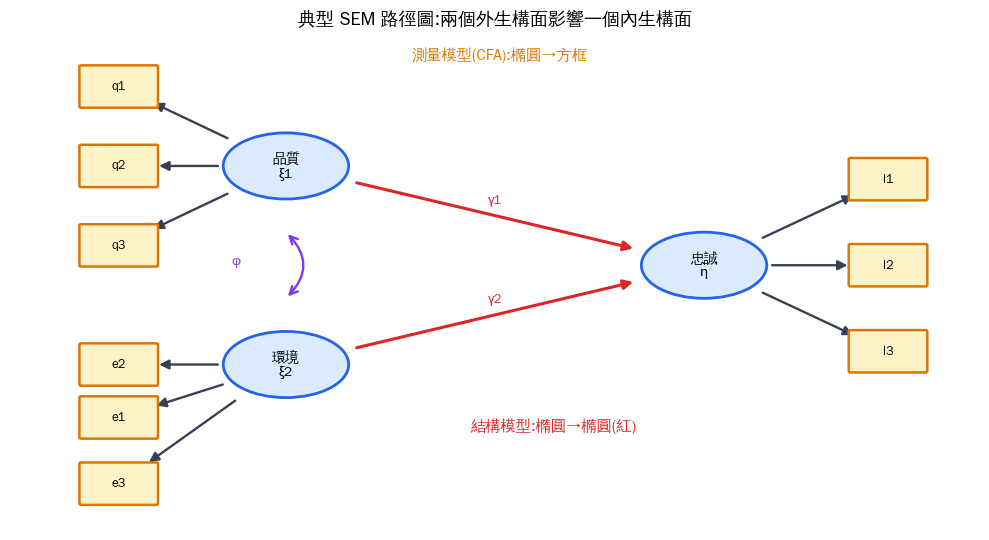

In [3]:
fig, ax = plt.subplots(figsize=(10, 5.5))
# 兩個外生潛在變項 -> 一個內生潛在變項;各 3 個指標
node(ax,(2,4),"品質\nξ1"); node(ax,(2,1),"環境\nξ2"); node(ax,(7,2.5),"忠誠\nη")
# 品質指標
for i,y in enumerate([5.2,4,2.8]):
    node(ax,(0,y),f"q{i+1}",kind="obs",w=0.9,h=0.6,fs=9); arrow(ax,(2,4),(0,y),r1=0.78,r2=0.45)
# 環境指標
for i,y in enumerate([0.2,1,-0.8]):
    node(ax,(0,y),f"e{i+1}",kind="obs",w=0.9,h=0.6,fs=9); arrow(ax,(2,1),(0,y),r1=0.78,r2=0.45)
# 忠誠指標
for i,y in enumerate([3.8,2.5,1.2]):
    node(ax,(9.2,y),f"l{i+1}",kind="obs",w=0.9,h=0.6,fs=9); arrow(ax,(7,2.5),(9.2,y),r1=0.78,r2=0.45)
# 結構路徑
arrow(ax,(2,4),(7,2.5),label="γ1",color="#dc2626",lw=2.2,r1=0.85,r2=0.85)
arrow(ax,(2,1),(7,2.5),label="γ2",color="#dc2626",lw=2.2,r1=0.85,r2=0.85)
# 外生潛在變項相關
arrow(ax,(2,3.5),(2,1.5),two_head=True,curved=-0.5,color="#7c3aed",label="φ",r1=0.5,r2=0.5,dx=-0.6,dy=0)
ax.text(3.5,5.6,"測量模型(CFA):橢圓→方框",color="#d97706",fontsize=11)
ax.text(4.2,0.0,"結構模型:橢圓→橢圓(紅)",color="#dc2626",fontsize=11)
ax.set_xlim(-1.3,10.3); ax.set_ylim(-1.5,6); ax.axis("off")
ax.set_title("典型 SEM 路徑圖:兩個外生構面影響一個內生構面",fontsize=13)
plt.tight_layout(); plt.show()

---
## 第 2 章　路徑分析與追蹤法則 (Wright's Tracing Rules)

在碰潛在變項之前,先用**只有觀察變項**的路徑分析,把「模型如何推導出相關」這件事學透。這是理解 $\Sigma(\theta)$ 的基礎。

### 2-1　路徑係數

在標準化(每個變項平均 0、變異數 1)之下,一條箭頭上的**路徑係數**就是「因變動 1 個標準差,果跟著變動幾個標準差」。對最簡單的單一原因,它等於相關係數;對多重原因,它等於(標準化)迴歸係數。

### 2-2　Wright 追蹤法則

要算任兩個變項的**模型隱含相關**,把連接它們的所有「合法路徑」找出來,**每條路徑上的係數相乘,再把各路徑加總**。合法路徑規則:

1. 同一個變項不能經過兩次(不可繞圈)。
2. 不可「先順箭頭、再逆箭頭」(可以先逆再順,因為共同原因會製造相關)。
3. 一條路徑最多只能經過一個雙箭頭(相關)。

### 2-3　數值案例:中介模型 (mediation)

模型:$X\to M\to Y$,且 $X\to Y$ 有直接路徑。係數 $a=X\to M$,$b=M\to Y$,$c'=X\to Y$。

用追蹤法則拆解 $X$ 與 $Y$ 的相關:

$$r_{XY}=\underbrace{c'}_{\text{直接效果}}+\underbrace{a\cdot b}_{\text{間接效果(經 }M\text{ 中介)}}$$

- **直接效果** = $c'$
- **間接效果(中介效果)** = $a\cdot b$
- **總效果** = $c'+a\cdot b$

取 $a=0.6,\;b=0.5,\;c'=0.2$,則間接 $=0.30$、總效果 $=0.50$。下面用模擬資料 + 迴歸驗證。

In [4]:
rng = np.random.default_rng(1)
N = 200000
a, b, cp = 0.6, 0.5, 0.2
X  = rng.standard_normal(N)
M  = a*X + np.sqrt(1-a**2)*rng.standard_normal(N)              # M 標準化
varYexp = cp**2 + b**2 + 2*cp*b*a                              # Var(c'X + bM)
Y  = cp*X + b*M + np.sqrt(1-varYexp)*rng.standard_normal(N)    # Y 標準化

r_XY = np.corrcoef(X, Y)[0,1]
print(f"模擬出的 r(X,Y)         = {r_XY:.4f}")
print(f"追蹤法則 c' + a·b        = {cp} + {a*b} = {cp + a*b}")
print(f"  ├ 直接效果  c'         = {cp}")
print(f"  └ 間接效果  a·b(中介)= {a*b}")
print(f"總效果                   = {cp + a*b}")

# 用迴歸把 a, b, c' 估回來(驗證路徑係數=標準化迴歸係數)
import numpy.linalg as la
def std_beta(yv, *xs):
    Xmat = np.column_stack([np.ones(N)] + [ (xi-xi.mean())/xi.std() for xi in xs ])
    yv2 = (yv-yv.mean())/yv.std()
    return la.lstsq(Xmat, yv2, rcond=None)[0][1:]
print("\n迴歸還原: a =", round(std_beta(M, X)[0],3),
      "| (c', b) =", np.round(std_beta(Y, X, M),3), " (真實 0.2, 0.5)")

模擬出的 r(X,Y)         = 0.4980
追蹤法則 c' + a·b        = 0.2 + 0.3 = 0.5
  ├ 直接效果  c'         = 0.2
  └ 間接效果  a·b(中介)= 0.3
總效果                   = 0.5



迴歸還原: a = 0.6 | (c', b) = [0.197 0.502]  (真實 0.2, 0.5)


### 2-4　從追蹤法則到 $\Sigma(\theta)$

追蹤法則其實就是在「**用模型的係數,反推每一對變項應該有的相關/共變異數**」——這正是 $\Sigma(\theta)$ 的由來。把所有變項對的隱含相關排成方陣,就是模型隱含共變異數矩陣。SEM 再拿它去逼近資料的 $S$。

> 矩陣形式:對只有觀察變項的路徑模型,$\Sigma(\theta)=(I-P)^{-1}\,\Psi\,(I-P)^{-\top}$,其中 $P$ 是路徑係數矩陣、$\Psi$ 是殘差(干擾)共變異數。追蹤法則就是這個矩陣公式展開後的「逐條路徑」版本。

---
## 第 3 章　測量模型 (CFA):推導 $\Sigma=\Lambda\Phi\Lambda'+\Theta$

### 3-1　測量方程式

每個觀察變項(題目)= 負荷量 × 潛在構面 + 測量誤差:

$$\boxed{\;x=\Lambda\,\xi+\delta\;}$$

- $x$:$p\times1$ 觀察變項向量(題目分數)
- $\Lambda$:$p\times m$ **因素負荷量矩陣**(每題對每個構面的負荷)
- $\xi$:$m\times1$ 潛在構面向量
- $\delta$:$p\times1$ 測量誤差(各題獨有、彼此無關)

### 3-2　推導隱含共變異數矩陣

假設 $\xi$ 與 $\delta$ 不相關、$E[\xi]=E[\delta]=0$。令 $\Phi=\mathrm{Cov}(\xi)$、$\Theta=\mathrm{Cov}(\delta)$(對角)。則:

$$
\Sigma=\mathrm{Cov}(x)=\mathrm{Cov}(\Lambda\xi+\delta)
=\Lambda\,\mathrm{Cov}(\xi)\,\Lambda'+\mathrm{Cov}(\delta)
$$

$$\boxed{\;\Sigma=\Lambda\,\Phi\,\Lambda'+\Theta\;}$$

(中間的交叉項 $\mathrm{Cov}(\Lambda\xi,\delta)=0$,因為構面與誤差不相關。)

**這就是 CFA 的模型隱含共變異數矩陣。** 注意它和上一份教材因素分析的 $\sqrt{\lambda}\,\vec e$ 是同一套東西的不同寫法——負荷量的平方貢獻共同性,誤差變異 $\Theta$ 貢獻獨特性。

### 3-3　數值案例:單因素 3 指標

取 $\Lambda=(0.8,0.7,0.6)'$,$\Phi=[1]$(標準化構面),誤差變異讓每題總變異 = 1,即 $\theta_i=1-\lambda_i^2$。逐元素:

- 對角(變異):$\sigma_{ii}=\lambda_i^2\cdot1+\theta_i=\lambda_i^2+(1-\lambda_i^2)=1$
- 非對角(共變異 = 此處即相關):$\sigma_{ij}=\lambda_i\lambda_j$

例如 $\sigma_{12}=0.8\times0.7=0.56$。下面用程式建出整個 $\Sigma$。

In [5]:
Lam = np.array([[0.8],[0.7],[0.6]])      # 3x1 負荷量
Phi = np.array([[1.0]])                   # 標準化構面
theta = 1 - Lam.flatten()**2             # 誤差變異 = 1 - λ²
Theta = np.diag(theta)

Sigma = Lam @ Phi @ Lam.T + Theta
print("負荷量 λ:", Lam.flatten())
print("誤差變異 θ:", np.round(theta,4))
print("\n模型隱含共變異數矩陣 Σ = ΛΦΛ' + Θ:\n", np.round(Sigma,4))
print("\n驗證:對角線應為 1(標準化)→", np.round(np.diag(Sigma),4))
print("驗證 σ12 = λ1·λ2 =", 0.8*0.7, "→ 矩陣中:", round(Sigma[0,1],4))

負荷量 λ: [0.8 0.7 0.6]
誤差變異 θ: [0.36 0.51 0.64]

模型隱含共變異數矩陣 Σ = ΛΦΛ' + Θ:
 [[1.   0.56 0.48]
 [0.56 1.   0.42]
 [0.48 0.42 1.  ]]

驗證:對角線應為 1(標準化)→ [1. 1. 1.]
驗證 σ12 = λ1·λ2 = 0.5599999999999999 → 矩陣中: 0.56


---
## 第 4 章　結構模型:潛在變項之間的迴歸

### 4-1　結構方程式 (LISREL 記法)

把構面分成兩類:**外生 (exogenous)** $\xi$(模型裡沒有箭頭指向它)與**內生 (endogenous)** $\eta$(有箭頭指向它)。結構模型寫成:

$$\boxed{\;\eta=B\,\eta+\Gamma\,\xi+\zeta\;}$$

- $B$:內生構面**彼此之間**的路徑係數(對角為 0)
- $\Gamma$:外生 → 內生的路徑係數
- $\zeta$:結構殘差(干擾, disturbance),即內生構面沒被解釋到的部分

### 4-2　簡化式 (reduced form)

把 $\eta$ 解出來(移項):

$$\eta-B\eta=\Gamma\xi+\zeta\;\Rightarrow\;(I-B)\eta=\Gamma\xi+\zeta$$
$$\boxed{\;\eta=(I-B)^{-1}(\Gamma\xi+\zeta)\;}$$

那個 $(I-B)^{-1}$ 正是把「直接 + 間接(經其他內生構面中介)」的所有效果一次加總起來的數學裝置——對應第 2 章的追蹤法則。

### 4-3　完整 SEM 的隱含共變異數

把測量模型($x=\Lambda_x\xi+\delta$、$y=\Lambda_y\eta+\varepsilon$)與結構模型組合,整個觀察向量的隱含共變異數矩陣可由 $\Lambda,B,\Gamma,\Phi,\Psi,\Theta$ 推導出來(完整公式較長,概念上就是「測量層 × 結構層 × 測量層 + 誤差」的堆疊)。

### 4-4　一個關鍵的觀念橋

> 當結構部分是**剛好辨識 (just-identified)**(例如兩個構面之間只有一條路徑),完整 SEM 的隱含共變異數矩陣會**等同於**「把那兩個構面當成相關因素」的 CFA。此時**結構路徑係數 = 因素間相關 $\phi$**。
>
> 這就是為什麼下一章我們**先手刻一個含因素相關的 CFA 估計器**,就已經能估出結構關係——因素相關 $\phi$ 在剛好辨識下正是標準化的結構路徑。當結構模型「過度辨識」(路徑比相關少)時,SEM 才會真正比 CFA 多出檢驗力,這部分留給第 7 章的 `semopy`。

---
## 第 5 章　參數估計:手刻最大概似 (ML) 估計器

### 5-1　從常態概似推導 $F_{ML}$

假設 $p$ 個觀察變項服從多元常態 $N(0,\Sigma)$。$N$ 筆資料的對數概似(已置中、省略平均數結構):

$$\log L(\theta)=-\frac{N}{2}\Big[\,p\log(2\pi)+\log|\Sigma(\theta)|+\mathrm{tr}\big(S\,\Sigma(\theta)^{-1}\big)\Big]$$

其中 $S$ 是樣本共變異數矩陣(此處用 $N$ 當分母)。**最大化 $\log L$** 等價於**最小化**:

$$f(\theta)=\log|\Sigma(\theta)|+\mathrm{tr}\big(S\,\Sigma(\theta)^{-1}\big)$$

為了讓「完美適配($\Sigma=S$)時函數值 = 0」,扣掉飽和模型的常數,得到 SEM 標準的**差異函數 (discrepancy function)**:

$$\boxed{\;F_{ML}(\theta)=\log|\Sigma(\theta)|+\mathrm{tr}\big(S\,\Sigma(\theta)^{-1}\big)-\log|S|-p\;}$$

性質:$F_{ML}\ge0$,且 $=0\iff\Sigma(\theta)=S$。**SEM 估計 = 找 $\theta$ 讓 $F_{ML}$ 最小。**

### 5-2　手刻估計器:2 因素 CFA(含因素相關 = 結構路徑)

我們模擬一份資料:兩個構面 $\xi_1,\xi_2$ 各 3 個指標,**真實因素相關 = 0.5**(即標準化結構路徑 0.5)。然後從零寫出 $F_{ML}$,用 `scipy.optimize` 找最小值,看能不能把負荷量與那條 0.5 的結構關係**還原**回來。

In [6]:
# --- 模擬資料:2 構面、各 3 指標、因素相關(=結構路徑)= 0.5 ---
rng = np.random.default_rng(0)
N = 400
F = rng.multivariate_normal([0,0], [[1,0.5],[0.5,1]], size=N)
L_true = np.array([0.8,0.7,0.6, 0.75,0.65,0.55])
belong = [0,0,0,1,1,1]
Xobs = np.zeros((N,6))
for j,f in enumerate(belong):
    Xobs[:,j] = L_true[j]*F[:,f] + np.sqrt(1-L_true[j]**2)*rng.standard_normal(N)

p = 6
S = np.cov(Xobs, rowvar=False, bias=True)     # ML:分母用 N
print("樣本共變異數矩陣 S:\n", np.round(S,3))

樣本共變異數矩陣 S:
 [[0.928 0.56  0.46  0.336 0.223 0.15 ]
 [0.56  1.042 0.418 0.264 0.162 0.101]
 [0.46  0.418 1.034 0.297 0.206 0.122]
 [0.336 0.264 0.297 0.994 0.522 0.331]
 [0.223 0.162 0.206 0.522 0.978 0.335]
 [0.15  0.101 0.122 0.331 0.335 1.023]]


In [7]:
# --- 從零定義模型:Σ(θ) = ΛΦΛ' + Θ ---
def unpack(theta):
    lam = theta[:6]                  # 6 個負荷量
    rho = np.tanh(theta[6])          # 因素相關,tanh 限制在 (-1,1)
    th  = np.exp(theta[7:13])        # 6 個誤差變異,exp 保證 > 0
    Lam = np.zeros((6,2))
    for j,f in enumerate(belong): Lam[j,f] = lam[j]
    Phi = np.array([[1.0, rho],[rho, 1.0]])     # 因素變異固定為 1(標準化辨識)
    Sigma = Lam @ Phi @ Lam.T + np.diag(th)
    return Lam, Phi, th, rho, Sigma

# --- 差異函數 F_ML ---
_, logdetS = np.linalg.slogdet(S)
def F_ML(theta):
    *_, Sigma = unpack(theta)
    sign, logdet = np.linalg.slogdet(Sigma)
    if sign <= 0: return 1e10                    # 非正定 → 罰
    return logdet + np.trace(S @ np.linalg.inv(Sigma)) - logdetS - p

# --- 最佳化:找讓 F_ML 最小的參數 ---
theta0 = np.concatenate([np.full(6,0.7), [0.0], np.log(np.full(6,0.5))])
res = minimize(F_ML, theta0, method="Nelder-Mead",
               options={"maxiter":30000,"xatol":1e-9,"fatol":1e-11})
Lam, Phi, th, rho, Sigma = unpack(res.x)

print("收斂:", res.success, "| F_min =", round(res.fun,5))
est = pd.DataFrame({"指標":[f"x{i+1}" for i in range(6)],
                    "估計負荷量":np.round(Lam.sum(axis=1),3),
                    "真實負荷量":L_true,
                    "估計誤差變異":np.round(th,3)})
print(est.to_string(index=False))
print(f"\n>>> 估計因素相關(=標準化結構路徑)= {rho:.3f}   真實 = 0.5")

收斂: True | F_min = 0.02198
指標  估計負荷量  真實負荷量  估計誤差變異
x1  0.792   0.80   0.301
x2  0.699   0.70   0.553
x3  0.594   0.60   0.681
x4  0.805   0.75   0.346
x5  0.653   0.65   0.552
x6  0.435   0.55   0.833

>>> 估計因素相關(=標準化結構路徑)= 0.491   真實 = 0.5


看到了嗎?從零寫出來的估計器,把 6 個負荷量和那條 **0.5 的結構關係**都還原回來了。**整個 SEM 軟體(LISREL、Amos、Mplus、lavaan、semopy)骨子裡做的就是這件事:最小化 $F_{ML}$。** 下一章我們用同一個 `F_min` 算適配度。

---
## 第 6 章　適配度指標 (Fit Indices)

模型估完後,要回答:「$\Sigma(\hat\theta)$ 到底貼 $S$ 貼得多好?」這就是適配度。

### 6-1　卡方檢定 $\chi^2$ 與自由度 df

$$\chi^2=(N-1)\cdot F_{min},\qquad df=\underbrace{\frac{p(p+1)}{2}}_{S\text{ 中獨立元素數}}-\underbrace{q}_{\text{自由參數數}}$$

虛無假設是「模型正確($\Sigma(\theta)=S$)」,所以 $\chi^2$ **不顯著(p 值大)反而是好事**。但 $\chi^2$ 對樣本數敏感,故另有下列指標。

### 6-2　常用近似適配指標

| 指標 | 公式 | 判準(越…越好) |
|---|---|---|
| **RMSEA** | $\sqrt{\dfrac{\max(\chi^2-df,\,0)}{df\,(N-1)}}$ | $<0.06$ 佳 |
| **CFI** | $1-\dfrac{\max(\chi^2-df,0)}{\max(\chi^2-df,\;\chi^2_b-df_b,\,0)}$ | $>0.95$ 佳 |
| **TLI** | $\dfrac{\chi^2_b/df_b-\chi^2/df}{\chi^2_b/df_b-1}$ | $>0.95$ 佳 |
| **SRMR** | 標準化殘差 $(S-\Sigma)$ 的均方根 | $<0.08$ 佳 |

其中下標 $b$ 指**基準(獨立)模型**:假設所有觀察變項互不相關($\Sigma_b=\mathrm{diag}(S)$),$df_b=\dfrac{p(p-1)}{2}$。CFI/TLI 衡量「你的模型比『什麼關係都沒有』的爛模型好多少」。

### 6-3　用第 5 章的估計結果實際計算

In [8]:
q = 13                                   # 自由參數:6 負荷 + 1 相關 + 6 誤差變異
Fmin = res.fun
df   = p*(p+1)//2 - q
chi2 = (N-1)*Fmin

# 基準(獨立)模型:Σ_b = diag(S)
Sigma_b = np.diag(np.diag(S))
sign_b, logdet_b = np.linalg.slogdet(Sigma_b)
Fmin_b = logdet_b + np.trace(S @ np.linalg.inv(Sigma_b)) - logdetS - p
df_b   = p*(p-1)//2
chi2_b = (N-1)*Fmin_b

rmsea = np.sqrt(max(chi2-df,0)/(df*(N-1)))
cfi   = 1 - max(chi2-df,0)/max(chi2-df, chi2_b-df_b, 1e-12)
tli   = ((chi2_b/df_b) - (chi2/df)) / ((chi2_b/df_b) - 1)

# SRMR:標準化殘差矩陣的均方根(下三角含對角)
d = np.sqrt(np.diag(S))
resid_corr = (S - Sigma) / np.outer(d, d)
tril = np.tril_indices(p)
srmr = np.sqrt((resid_corr[tril]**2).mean())

print(f"χ² = {chi2:.3f}   df = {df}   χ²/df = {chi2/df:.3f}")
print(f"基準模型 χ²_b = {chi2_b:.1f}  (df_b = {df_b})")
print("-"*40)
print(f"RMSEA = {rmsea:.4f}   (< 0.06 佳)")
print(f"CFI   = {cfi:.4f}   (> 0.95 佳)")
print(f"TLI   = {tli:.4f}   (> 0.95 佳)")
print(f"SRMR  = {srmr:.4f}   (< 0.08 佳)")
print("\n結論:各指標皆達標 → 模型適配良好,$\\Sigma(\\hat\\theta)$ 成功重現了 S。")

χ² = 8.769   df = 8   χ²/df = 1.096
基準模型 χ²_b = 529.2  (df_b = 15)
----------------------------------------
RMSEA = 0.0155   (< 0.06 佳)
CFI   = 0.9985   (> 0.95 佳)
TLI   = 0.9972   (> 0.95 佳)
SRMR  = 0.0270   (< 0.08 佳)

結論:各指標皆達標 → 模型適配良好,$\Sigma(\hat\theta)$ 成功重現了 S。


---
## 第 7 章　完整實作:用 `semopy` 跑潛在變項 SEM

手刻估計器讓你懂了原理。實務上用專業套件,可以處理**過度辨識的結構模型**(這才是 SEM 勝過 CFA 之處)。

**情境**:兩個外生構面「品質 (Quality)」「環境 (Env)」共同影響一個內生構面「忠誠 (Loyalty)」,各構面 3 個指標。真實結構係數 $Q\to L=0.5$、$E\to L=0.3$。

In [9]:
import semopy

# --- 模擬潛在變項 SEM 資料 ---
rng = np.random.default_rng(7)
N = 1000
xiQ = rng.standard_normal(N); xiE = rng.standard_normal(N)
Loy = 0.5*xiQ + 0.3*xiE + np.sqrt(1-(0.5**2+0.3**2))*rng.standard_normal(N)
def ind(f, loads):
    return np.column_stack([l*f + np.sqrt(1-l**2)*rng.standard_normal(N) for l in loads])
data = pd.DataFrame(
    np.column_stack([ind(xiQ,[0.8,0.75,0.7]), ind(xiE,[0.8,0.7,0.6]), ind(Loy,[0.85,0.8,0.7])]),
    columns=["q1","q2","q3","e1","e2","e3","l1","l2","l3"])

# --- 用 semopy 語法描述模型 ---
desc = '''
# 測量模型 (=~ 讀作「由…測量」)
Quality =~ q1 + q2 + q3
Env     =~ e1 + e2 + e3
Loyalty =~ l1 + l2 + l3
# 結構模型 (~ 讀作「被…預測」)
Loyalty ~ Quality + Env
'''
model = semopy.Model(desc)
model.fit(data)
ins = model.inspect(std_est=True)        # 取標準化解
struct = ins[ins["op"]=="~"]
print("結構路徑(標準化):")
print(struct[["lval","op","rval","Est. Std","p-value"]].to_string(index=False))

結構路徑(標準化):
   lval op    rval  Est. Std p-value
Loyalty  ~ Quality    0.4975     0.0
Loyalty  ~     Env    0.2948     0.0
     q1  ~ Quality    0.7824       -
     q2  ~ Quality    0.7274     0.0
     q3  ~ Quality    0.6886     0.0
     e1  ~     Env    0.7908       -
     e2  ~     Env    0.7368     0.0
     e3  ~     Env    0.6069     0.0
     l1  ~ Loyalty    0.8212       -
     l2  ~ Loyalty    0.8212     0.0
     l3  ~ Loyalty    0.6957     0.0


In [10]:
# --- 適配度 ---
stats = semopy.calc_stats(model).T
print("適配度指標:")
for k in ["chi2","DoF","chi2 p-value","CFI","TLI","RMSEA"]:
    try:
        v = float(stats.loc[k].iloc[0]); print(f"  {k:14s}= {v:.4f}")
    except Exception:
        pass

適配度指標:
  chi2          = 19.2646
  DoF           = 24.0000
  chi2 p-value  = 0.7377
  CFI           = 1.0016
  TLI           = 1.0025
  RMSEA         = 0.0000


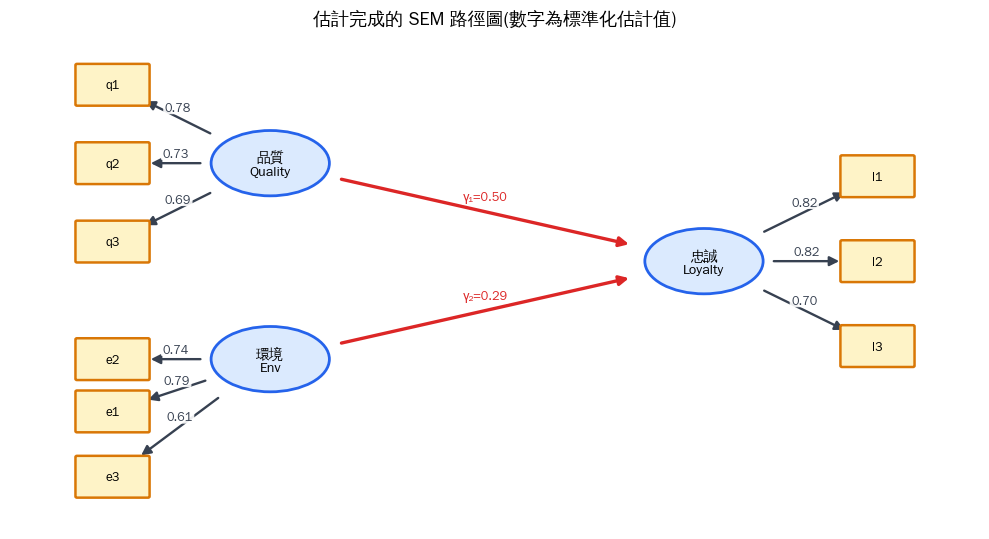

標準化結構路徑:品質→忠誠 = 0.498(真實 0.5),環境→忠誠 = 0.295(真實 0.3)


In [11]:
# --- 把估計結果畫成路徑圖 ---
ins_all = model.inspect(std_est=True)
def _lookup(lval, rval):
    row = ins_all[(ins_all["lval"]==lval)&(ins_all["rval"]==rval)&(ins_all["op"]=="~")]
    return float(row["Est. Std"].iloc[0]) if len(row) else np.nan
def get_load(indicator, factor):   # semopy 的負荷量:lval=指標, rval=構面
    return _lookup(indicator, factor)
def get_struct(endo, exo):         # 結構路徑:lval=內生, rval=外生
    return _lookup(endo, exo)
gQ = get_struct("Loyalty","Quality"); gE = get_struct("Loyalty","Env")

fig, ax = plt.subplots(figsize=(10,5.5))
node(ax,(2,4),"品質\nQuality"); node(ax,(2,1),"環境\nEnv"); node(ax,(7.5,2.5),"忠誠\nLoyalty")
for i,(y,nm) in enumerate(zip([5.2,4,2.8],["q1","q2","q3"])):
    node(ax,(0,y),nm,kind="obs",w=0.9,h=0.6,fs=9)
    arrow(ax,(2,4),(0,y),r1=0.85,r2=0.45,label=f"{get_load(nm,'Quality'):.2f}",dy=0.1)
for i,(y,nm) in enumerate(zip([0.2,1,-0.8],["e1","e2","e3"])):
    node(ax,(0,y),nm,kind="obs",w=0.9,h=0.6,fs=9)
    arrow(ax,(2,1),(0,y),r1=0.85,r2=0.45,label=f"{get_load(nm,'Env'):.2f}",dy=0.1)
for i,(y,nm) in enumerate(zip([3.8,2.5,1.2],["l1","l2","l3"])):
    node(ax,(9.7,y),nm,kind="obs",w=0.9,h=0.6,fs=9)
    arrow(ax,(7.5,2.5),(9.7,y),r1=0.85,r2=0.45,label=f"{get_load(nm,'Loyalty'):.2f}",dy=0.1)
arrow(ax,(2,4),(7.5,2.5),label=f"γ₁={gQ:.2f}",color="#dc2626",lw=2.4,r1=0.9,r2=0.95)
arrow(ax,(2,1),(7.5,2.5),label=f"γ₂={gE:.2f}",color="#dc2626",lw=2.4,r1=0.9,r2=0.95)
ax.set_xlim(-1.3,11); ax.set_ylim(-1.6,6); ax.axis("off")
ax.set_title("估計完成的 SEM 路徑圖(數字為標準化估計值)",fontsize=13)
plt.tight_layout(); plt.show()
print(f"標準化結構路徑:品質→忠誠 = {gQ:.3f}(真實 0.5),環境→忠誠 = {gE:.3f}(真實 0.3)")

---
## 第 8 章　總整理與練習

### 8-1　一張表貫穿 SEM

| 概念 | 數學 | 在 SEM 裡的角色 |
|---|---|---|
| 測量模型 | $x=\Lambda\xi+\delta$ | 潛在構面如何由題目反映(= CFA) |
| 結構模型 | $\eta=B\eta+\Gamma\xi+\zeta$ | 構面之間誰影響誰 |
| 隱含共變異數 | $\Sigma(\theta)=\Lambda\Phi\Lambda'+\Theta$(及結構層) | 模型「預測」的相關結構 |
| 追蹤法則 | 逐條路徑係數相乘相加 | 手算 $\Sigma(\theta)$ 的直覺版 |
| 估計 | $\min F_{ML}=\log|\Sigma|+\mathrm{tr}(S\Sigma^{-1})-\log|S|-p$ | 找 $\theta$ 讓 $\Sigma(\theta)\approx S$ |
| 適配度 | $\chi^2=(N-1)F_{min}$、RMSEA、CFI、TLI、SRMR | 評估貼合程度 |

> **核心思想再寫一次**:SEM = 把你對「誰影響誰」的理論,翻譯成一個隱含共變異數矩陣 $\Sigma(\theta)$,再用最大概似找參數,讓它逼近資料的 $S$。

### 8-2　SEM 與前一份教材的關係

$$
\text{特徵值 / PCA}\;\subset\;\text{因素分析(找構面)}\;\subset\;\text{CFA(驗證構面)}\;\subset\;\text{SEM(構面 + 因果)}
$$

一層一層往外包:SEM 把因素分析當成自己的「測量模型」那一半,再加上構面之間的因果結構。

### 8-3　練習題

**練習 1**　模型 $X\to M\to Y$(無直接路徑),$a=0.7,\;b=0.4$。用追蹤法則求 $r_{XY}$、間接效果、總效果。

**練習 2**　單因素 4 指標,$\Lambda=(0.9,0.8,0.7,0.6)'$,構面標準化,各題總變異 1。寫出 $\Sigma$ 的 $\sigma_{12}$ 與 $\sigma_{34}$,並說明對角線為何全是 1。

**練習 3**　某 SEM 有 $p=10$ 個觀察變項、估了 $q=23$ 個自由參數。求自由度 df。若 $N=250$、$F_{min}=0.18$,求 $\chi^2$ 與 RMSEA。

下一格為解答。

In [12]:
print("===== 練習 1 =====")
a,b = 0.7,0.4
print(f"r(X,Y)=間接=a·b={a*b};無直接路徑→直接=0;總效果={a*b}")

print("\n===== 練習 2 =====")
L = np.array([0.9,0.8,0.7,0.6])
print(f"σ12 = λ1·λ2 = {L[0]*L[1]:.2f};σ34 = λ3·λ4 = {L[2]*L[3]:.2f}")
print("對角線 σii = λi²·1 +(1-λi²) = 1,因構面標準化且各題總變異設為 1。")

print("\n===== 練習 3 =====")
p,q,N,Fmin = 10,23,250,0.18
df = p*(p+1)//2 - q
chi2 = (N-1)*Fmin
rmsea = np.sqrt(max(chi2-df,0)/(df*(N-1)))
print(f"df = {p}×{p+1}/2 − {q} = {p*(p+1)//2} − {q} = {df}")
print(f"χ² = (N−1)·F_min = {N-1}×{Fmin} = {chi2:.2f}")
print(f"RMSEA = √(max({chi2:.0f}−{df},0)/({df}×{N-1})) = {rmsea:.4f}")

===== 練習 1 =====
r(X,Y)=間接=a·b=0.27999999999999997;無直接路徑→直接=0;總效果=0.27999999999999997

===== 練習 2 =====
σ12 = λ1·λ2 = 0.72;σ34 = λ3·λ4 = 0.42
對角線 σii = λi²·1 +(1-λi²) = 1,因構面標準化且各題總變異設為 1。

===== 練習 3 =====
df = 10×11/2 − 23 = 55 − 23 = 32
χ² = (N−1)·F_min = 249×0.18 = 44.82
RMSEA = √(max(45−32,0)/(32×249)) = 0.0401


---
### 結語

你現在握有一條完整的理解鏈:

1. **追蹤法則**讓你看懂「模型如何生出相關」;
2. **$\Sigma=\Lambda\Phi\Lambda'+\Theta$** 把這件事寫成矩陣;
3. **$F_{ML}$** 告訴你怎麼找參數讓模型貼近資料;
4. **適配度指標**告訴你貼得好不好;
5. **`semopy`** 讓你在真實研究裡一行行寫出模型。

而這一切的最深處,仍然是上一份教材的主角——**共變異數矩陣的特徵結構**:不論因素分析或 SEM,都是在拆解、重建一個共變異數矩陣。SEM 只是讓你能對「構面之間的因果」下手而已。